In [2]:
# We Incorporate Long Term Memory with SQLSaver
# Inmemorysaver() is limited to session

from langgraph.graph import MessagesState
class MessagesState(MessagesState):
  pass

In [2]:

pip install -U langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.6/561.6 kB 16.8 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.9
    Uninstalling langchain-core-1.4.9:
      Successfully uninstalled langchain-core-1.4.9


In [3]:
## For chat bot we need Interactive Message so first wen need LLM
import os
from google.colab import userdata
os.environ['GOOGLE_API_KEY']=userdata.get('GEMINI5')

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash")

In [5]:
pip install -U duckduckgo-search langchain-community


In [6]:
pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 10.4 MB/s eta 0:00:00


In [6]:
# importing the tool Information
from langchain_core.tools import tool
from langgraph.prebuilt import tool_node, tools_condition


In [7]:
from langchain_community.tools import DuckDuckGoSearchResults
search = DuckDuckGoSearchResults()

/tmp/ipykernel_5361/3181357669.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchResults


In [25]:
# importing DUCk DUCK Search toola
@tool
def SearchEngine(query: str):
  ''' Like you afre the tool defined by the user so main thing is LLM is unaware about recent info,
  so Provide the updated information, gto model'''
  return search.run(query)

### Here we are interupting the system


In [26]:
from langgraph.types import interrupt, Command

### `interrupt`
- Temporarily pauses the graph execution and waits for external input (such as user approval or data) before continuing.

### `Command`
- Resumes the graph execution after an `interrupt` by providing the required input or specifying the next action.

In [27]:
@tool
def Systeminterupttool(response: str):
  '''
  you are a tool, your primary goal is to full fill the user problem for that
  you need to take suggestion and feedback from the user which will satesfies user input
  '''
  var1=interrupt(
      {
          'question':"Hello boss you like the notes design or alighnment of sentences , please give me the accurate feedback",
          'response':response

      }
  )


In [28]:
# Lets define Tools Node

tools=tool_node.ToolNode(
    tools=[SearchEngine, Systeminterupttool]
)

In [29]:
# let our LLM know these tools
Lmm_with_tools=llm.bind(tools=[SearchEngine, Systeminterupttool])

In [30]:
# Creating the Chat BOT NODES
def ChatNode(state :MessagesState ):
  response=Lmm_with_tools.invoke(state['messages'])
  return {'messages':[response] }

In [31]:
# Creating graph

from langgraph.graph import StateGraph, START, END


In [32]:
graph_var=StateGraph(MessagesState)

In [33]:
graph_var.add_node('ChatNode', ChatNode)
graph_var.add_node('tools',tools)

In [34]:
graph_var.add_edge(START, 'ChatNode')
graph_var.add_conditional_edges('ChatNode', tools_condition, {'tools':'tools' , END:END})
graph_var.add_edge( 'tools', 'ChatNode')

In [ ]:
pip install -U langgraph-checkpoint-sqlite

In [35]:
# Now add the Memory]
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver


In [36]:
checkpointer=sqlite3.connect('Mymemory.db', check_same_thread=False) # SO we can generate responses with diffrent threads
Memory=SqliteSaver(checkpointer)

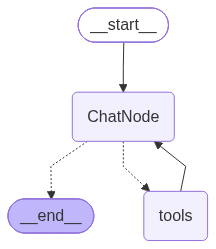

In [37]:
graph=graph_var.compile(checkpointer=Memory)
graph

In [38]:
from langchain_core.messages import HumanMessage, SystemMessage

In [41]:
system_prompt="""
Hello LLM i know you are expert in dealing things
Since you are an old model. you are unaware of recent things orUpdates
Always Take help from the tools inorder to prove the accurate information
->Take SearchEngine tool help inorder to get the recent information
->Always ask human feedback by invoking Systeminterupt tool
-> Only complete execution after taking human feedback
  """

In [42]:
res=graph.invoke({'messages':[SystemMessage(content=system_prompt),
                          HumanMessage(content='hello ')]},
                {'configurable': {'thread_id': 'user2'}}
                           )
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================


Hey LLM Iknow you are an expert, but many llms are unaware about the most recent news or affairs to take help of given tool and produce the answer,
 if you were aware of content just give answer in single word  with small description
Answer the user query acc to latest information provided by tool if you unaware
  if User ask who won IPL & tool gave BIG para sentence , consize it  : You should Answer like  : RCB  [a Bengaluru TEAM, Got troffy at NAMO stadium IPL 2026],
  if User ASK about india PM & tool gave BIG para sentence , consize it   :You should Answer : Narendra MODI [Member of parlament], Leader of ruling party, BJP
  Like wise Any today UPDATES or recent updates you answer in single word with small description
  
================================ Human Message =================================

hello 
================================== Ai Message ==================================

Hello! How c

In [43]:
res=graph.invoke({'messages':[SystemMessage(content=system_prompt),
                          HumanMessage(content='What matches are goingon in world recenttimes ')]},
                {'configurable': {'thread_id': 'user2'}}
                           )
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================


Hey LLM Iknow you are an expert, but many llms are unaware about the most recent news or affairs to take help of given tool and produce the answer,
 if you were aware of content just give answer in single word  with small description
Answer the user query acc to latest information provided by tool if you unaware
  if User ask who won IPL & tool gave BIG para sentence , consize it  : You should Answer like  : RCB  [a Bengaluru TEAM, Got troffy at NAMO stadium IPL 2026],
  if User ASK about india PM & tool gave BIG para sentence , consize it   :You should Answer : Narendra MODI [Member of parlament], Leader of ruling party, BJP
  Like wise Any today UPDATES or recent updates you answer in single word with small description
  
================================ Human Message =================================

hello 
================================== Ai Message ==================================

Hello! How c

#### Observe it is asking about Feedback

- Inorder to conform it is only asking feedback , just check  execution loop by
- `graph.getstate` then `interreputs`

In [46]:
st= graph.get_state({'configurable': {'thread_id': 'user2'}})

In [47]:
st.interrupts

(Interrupt(value={'question': 'Hello boss you like the notes design or alighnment of sentences , please give me the accurate feedback', 'response': 'Cricket: IPL 2026 and T20 World Cup 2026 are ongoing.\nFootball: Various matches are happening, and the FIFA World Cup 2026 schedule is available.\nIs there any specific sport or match you would like to know more about?'}, id='a423c6aa2d2ebe1e927f25a2791cce33'),)

- if graph.get_state -> Interupts is empty Then there is no interupts else the flow is paused due to system interuption
- so by using COMMAND resume the flow of execution

In [48]:
reply=Command(
    resume={
        "good Respone keepit up"
    }

)


In [49]:
Update= graph.invoke(reply,
                     {'configurable': {'thread_id': 'user2'}})

In [50]:
for every in Update['messages']:
  every.pretty_print()

================================ System Message ================================


Hey LLM Iknow you are an expert, but many llms are unaware about the most recent news or affairs to take help of given tool and produce the answer,
 if you were aware of content just give answer in single word  with small description
Answer the user query acc to latest information provided by tool if you unaware
  if User ask who won IPL & tool gave BIG para sentence , consize it  : You should Answer like  : RCB  [a Bengaluru TEAM, Got troffy at NAMO stadium IPL 2026],
  if User ASK about india PM & tool gave BIG para sentence , consize it   :You should Answer : Narendra MODI [Member of parlament], Leader of ruling party, BJP
  Like wise Any today UPDATES or recent updates you answer in single word with small description
  
================================ Human Message =================================

hello 
================================== Ai Message ==================================

Hello! How c

In [53]:
# Checking again flow is completely executed or not

Snapshot=graph.get_state({'configurable': {'thread_id': 'user2'}})
Snapshot.interrupts

()

Now the graph was completely executed

In [56]:
# Another EXample

res=graph.invoke({'messages':[SystemMessage(content=system_prompt),
                          HumanMessage(content='hello, BOT')]},
                {'configurable': {'thread_id': 'user3'}}
                           )
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================


Hello LLM i know you are expert in dealing things 
Since you are an old model. you are unaware of recent things orUpdates 
Always Take help from the tools inorder to prove the accurate information 
->Take SearchEngine tool help inorder to get the recent information
->Always ask human feedback by invoking Systeminterupt tool 
-> Only complete execution after taking human feedback
  
================================ Human Message =================================

hello, BOT
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'Cv0BARFNMg9doAdVmcwCqtaRcpADHDXgXpuk/c6SXgCE82or5lc2mS3jbMTMSKvOkVztjeDXDX7w38/OS7R2QG9JAkMlJgVJew08l1OsDxVWRhKuk1Fa+m7FKvjOUOsjxrxipJFi8G0vIjjpqGJkKULNzK/ZXi3r7DQSNM9E8LJBo9R39yN35F13+xo9He9cQ6yesA2soEKJrE0Z74mJaQEMxn4+DrzdYyUfKZiSQdFql9pGR9uGfGCcPTDMIVNI3rnv0Ol/y8MNH3

In [57]:
Snapshot=graph.get_state({'configurable': {'thread_id': 'user2'}})
Snapshot.interrupts

()

 It is not using Tools for Simple messages like hi bye

In [58]:
res=graph.invoke({'messages':[SystemMessage(content=system_prompt),
                          HumanMessage(content='my name is chidvilas')]},
                {'configurable': {'thread_id': 'user3'}}
                           )
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================


Hello LLM i know you are expert in dealing things 
Since you are an old model. you are unaware of recent things orUpdates 
Always Take help from the tools inorder to prove the accurate information 
->Take SearchEngine tool help inorder to get the recent information
->Always ask human feedback by invoking Systeminterupt tool 
-> Only complete execution after taking human feedback
  
================================ Human Message =================================

hello, BOT
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'Cv0BARFNMg9doAdVmcwCqtaRcpADHDXgXpuk/c6SXgCE82or5lc2mS3jbMTMSKvOkVztjeDXDX7w38/OS7R2QG9JAkMlJgVJew08l1OsDxVWRhKuk1Fa+m7FKvjOUOsjxrxipJFi8G0vIjjpqGJkKULNzK/ZXi3r7DQSNM9E8LJBo9R39yN35F13+xo9He9cQ6yesA2soEKJrE0Z74mJaQEMxn4+DrzdYyUfKZiSQdFql9pGR9uGfGCcPTDMIVNI3rnv0Ol/y8MNH3

In [59]:
Snapshot=graph.get_state({'configurable': {'thread_id': 'user2'}})
Snapshot.interrupts

()

In [60]:
res=graph.invoke({'messages':[SystemMessage(content=system_prompt),
                          HumanMessage(content='Thankyou')]},
                {'configurable': {'thread_id': 'user3'}}
                           )
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================


Hello LLM i know you are expert in dealing things 
Since you are an old model. you are unaware of recent things orUpdates 
Always Take help from the tools inorder to prove the accurate information 
->Take SearchEngine tool help inorder to get the recent information
->Always ask human feedback by invoking Systeminterupt tool 
-> Only complete execution after taking human feedback
  
================================ Human Message =================================

hello, BOT
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'Cv0BARFNMg9doAdVmcwCqtaRcpADHDXgXpuk/c6SXgCE82or5lc2mS3jbMTMSKvOkVztjeDXDX7w38/OS7R2QG9JAkMlJgVJew08l1OsDxVWRhKuk1Fa+m7FKvjOUOsjxrxipJFi8G0vIjjpqGJkKULNzK/ZXi3r7DQSNM9E8LJBo9R39yN35F13+xo9He9cQ6yesA2soEKJrE0Z74mJaQEMxn4+DrzdYyUfKZiSQdFql9pGR9uGfGCcPTDMIVNI3rnv0Ol/y8MNH3

In [61]:
Snapshot=graph.get_state({'configurable': {'thread_id': 'user2'}})
Snapshot.interrupts

()